In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

pd.set_option("display.max_columns", 200)
pd.set_option("display.float_format", "{:.4f}".format)

### Load the datasets

In [2]:
BASE = Path("../data/clean")

DAILY_PATH    = BASE / "daily_adjusted" / "ALL_daily_adjusted_clean.parquet"
INCOME_PATH   = BASE / "fundamentals" / "ALL_income_statement_clean.parquet"
BALANCE_PATH  = BASE / "fundamentals" / "ALL_balance_sheet_clean.parquet"
CASHFLOW_PATH = BASE / "fundamentals" / "ALL_cash_flow_clean.parquet"
OVERVIEW_PATH = BASE / "fundamentals" / "ALL_overview_clean.csv"
OPTIONS_PATH  = BASE / "options" / "ALL_options_clean.parquet"

print(DAILY_PATH)
print(INCOME_PATH)
print(BALANCE_PATH)
print(CASHFLOW_PATH)
print(OVERVIEW_PATH)
print(OPTIONS_PATH)

../data/clean/daily_adjusted/ALL_daily_adjusted_clean.parquet
../data/clean/fundamentals/ALL_income_statement_clean.parquet
../data/clean/fundamentals/ALL_balance_sheet_clean.parquet
../data/clean/fundamentals/ALL_cash_flow_clean.parquet
../data/clean/fundamentals/ALL_overview_clean.csv
../data/clean/options/ALL_options_clean.parquet


In [3]:
# Load the datasets
daily = pd.read_parquet(DAILY_PATH)
income = pd.read_parquet(INCOME_PATH)
balance = pd.read_parquet(BALANCE_PATH)
cashflow = pd.read_parquet(CASHFLOW_PATH)
overview = pd.read_csv(OVERVIEW_PATH)
options = pd.read_parquet(OPTIONS_PATH)

print("daily:", daily.shape)
print("income:", income.shape)
print("balance:", balance.shape)
print("cashflow:", cashflow.shape)
print("overview:", overview.shape)
print("options:", options.shape)

daily: (52486, 10)
income: (781, 22)
balance: (773, 33)
cashflow: (778, 17)
overview: (10, 55)
options: (3192217, 20)


In [4]:
# Parse date columns
daily["date"] = pd.to_datetime(daily["date"])

income["fiscalDateEnding"] = pd.to_datetime(income["fiscalDateEnding"])
balance["fiscalDateEnding"] = pd.to_datetime(balance["fiscalDateEnding"])
cashflow["fiscalDateEnding"] = pd.to_datetime(cashflow["fiscalDateEnding"])

print("Dates parsed.")

Dates parsed.


In [5]:
income.head()

,symbol,fiscalDateEnding,reportedCurrency,grossProfit,totalRevenue,costOfRevenue,costofGoodsAndServicesSold,operatingIncome,sellingGeneralAndAdministrative,researchAndDevelopment,operatingExpenses,netInterestIncome,interestIncome,interestExpense,otherNonOperatingIncome,depreciationAndAmortization,incomeBeforeTax,incomeTaxExpense,netIncomeFromContinuingOperations,ebit,ebitda,netIncome
0,AAPL,2005-12-31,USD,1564000000.0000,5749000000,4185000000,4185000000,750000000.0000,632000000.0000,182000000.0000,814000000.0000,348000000.0000,1358000000.0000,81000000.0000,60000000.0000,52000000.0000,831000000.0000,266000000.0000,0.0000,750000000.0000,802000000.0000,565000000.0000
1,AAPL,2006-03-31,USD,1297000000.0000,4359000000,3062000000,3062000000,529000000.0000,592000000.0000,176000000.0000,768000000.0000,348000000.0000,1358000000.0000,76000000.0000,60000000.0000,50000000.0000,605000000.0000,195000000.0000,0.0000,529000000.0000,579000000.0000,410000000.0000
2,AAPL,2006-06-30,USD,1325000000.0000,4370000000,3045000000,3045000000,566000000.0000,584000000.0000,175000000.0000,759000000.0000,348000000.0000,1358000000.0000,0.0000,60000000.0000,57000000.0000,661000000.0000,189000000.0000,0.0000,566000000.0000,623000000.0000,472000000.0000
3,AAPL,2006-09-30,USD,1412000000.0000,4370000000,3425000000,3425000000,608000000.0000,584000000.0000,179000000.0000,804000000.0000,348000000.0000,1358000000.0000,252000000.0000,60000000.0000,66000000.0000,721000000.0000,179000000.0000,0.0000,661000000.0000,718000000.0000,542000000.0000
4,AAPL,2006-12-31,USD,2220000000.0000,7115000000,4895000000,4895000000,1322000000.0000,714000000.0000,184000000.0000,898000000.0000,348000000.0000,1358000000.0000,126000000.0000,60000000.0000,74000000.0000,1448000000.0000,444000000.0000,0.0000,1322000000.0000,1396000000.0000,1004000000.0000


In [6]:
# Inspect columns before merging
print("DAILY COLUMNS")
print(daily.columns.tolist())

print("\nINCOME COLUMNS")
print(income.columns.tolist())

print("\nBALANCE COLUMNS")
print(balance.columns.tolist())

print("\nCASHFLOW COLUMNS")
print(cashflow.columns.tolist())

print("\nOVERVIEW COLUMNS")
print(overview.columns.tolist())

DAILY COLUMNS
['date', 'symbol', 'open', 'high', 'low', 'close', 'adj_close', 'volume', 'dividend', 'split_coeff']

INCOME COLUMNS
['symbol', 'fiscalDateEnding', 'reportedCurrency', 'grossProfit', 'totalRevenue', 'costOfRevenue', 'costofGoodsAndServicesSold', 'operatingIncome', 'sellingGeneralAndAdministrative', 'researchAndDevelopment', 'operatingExpenses', 'netInterestIncome', 'interestIncome', 'interestExpense', 'otherNonOperatingIncome', 'depreciationAndAmortization', 'incomeBeforeTax', 'incomeTaxExpense', 'netIncomeFromContinuingOperations', 'ebit', 'ebitda', 'netIncome']

BALANCE COLUMNS
['symbol', 'fiscalDateEnding', 'reportedCurrency', 'totalAssets', 'totalCurrentAssets', 'cashAndCashEquivalentsAtCarryingValue', 'cashAndShortTermInvestments', 'inventory', 'currentNetReceivables', 'totalNonCurrentAssets', 'propertyPlantEquipment', 'intangibleAssets', 'intangibleAssetsExcludingGoodwill', 'goodwill', 'longTermInvestments', 'shortTermInvestments', 'otherCurrentAssets', 'totalLiabil

### Keeping only important columns from the datasets

In [7]:
# From daily adjustments
daily_keep = [
    "date", "symbol", "open", "high", "low", "close",
    "adj_close", "volume", "dividend", "split_coeff"
]

daily = daily[daily_keep].copy()
daily.head()

,date,symbol,open,high,low,close,adj_close,volume,dividend,split_coeff
0,2009-08-06,AVGO,16.5000,16.9100,15.5600,16.1800,1.1560,24197800,0.0000,1.0000
1,2009-08-07,AVGO,16.1500,16.7600,16.0300,16.4300,1.1738,2454300,0.0000,1.0000
2,2009-08-10,AVGO,16.6300,16.6300,15.6100,15.9700,1.1410,2421000,0.0000,1.0000
3,2009-08-11,AVGO,15.9800,16.0000,15.5000,15.6700,1.1195,2305400,0.0000,1.0000
4,2009-08-12,AVGO,16.1500,16.2000,15.6600,16.0000,1.1431,1451300,0.0000,1.0000


In [8]:
# Income statement
income_keep = [
    "symbol", "fiscalDateEnding",
    "totalRevenue", "grossProfit", "operatingIncome",
    "operatingExpenses", "ebit", "ebitda", "netIncome"
]

income = income[[c for c in income_keep if c in income.columns]].copy()
income.head()

,symbol,fiscalDateEnding,totalRevenue,grossProfit,operatingIncome,operatingExpenses,ebit,ebitda,netIncome
0,AAPL,2005-12-31,5749000000,1564000000.0000,750000000.0000,814000000.0000,750000000.0000,802000000.0000,565000000.0000
1,AAPL,2006-03-31,4359000000,1297000000.0000,529000000.0000,768000000.0000,529000000.0000,579000000.0000,410000000.0000
2,AAPL,2006-06-30,4370000000,1325000000.0000,566000000.0000,759000000.0000,566000000.0000,623000000.0000,472000000.0000
3,AAPL,2006-09-30,4370000000,1412000000.0000,608000000.0000,804000000.0000,661000000.0000,718000000.0000,542000000.0000
4,AAPL,2006-12-31,7115000000,2220000000.0000,1322000000.0000,898000000.0000,1322000000.0000,1396000000.0000,1004000000.0000


In [9]:
# Balance sheet
balance_keep = [
    "symbol", "fiscalDateEnding",
    "totalAssets", "totalCurrentAssets",
    "cashAndCashEquivalentsAtCarryingValue",
    "totalLiabilities", "totalCurrentLiabilities",
    "longTermDebt", "totalShareholderEquity",
    "commonStockSharesOutstanding"
]

balance = balance[[c for c in balance_keep if c in balance.columns]].copy()
balance.head()

,symbol,fiscalDateEnding,totalAssets,totalCurrentAssets,cashAndCashEquivalentsAtCarryingValue,totalLiabilities,totalCurrentLiabilities,longTermDebt,totalShareholderEquity,commonStockSharesOutstanding
0,AAPL,2005-12-31,14181000000.0000,11691000000.0000,4150000000.0000,5801000000.0000,5060000000.0000,0.0000,8380000000.0000,24477796000.0000
1,AAPL,2006-03-31,13911000000.0000,10730000000.0000,6346000000.0000,5229000000.0000,4456000000.0000,0.0000,8682000000.0000,24599036000.0000
2,AAPL,2006-06-30,15114000000.0000,11486000000.0000,8013000000.0000,5784000000.0000,5023000000.0000,0.0000,9330000000.0000,24538304000.0000
3,AAPL,2006-09-30,17205000000.0000,13758000000.0000,6392000000.0000,7221000000.0000,6471000000.0000,0.0000,9984000000.0000,24538304000.0000
4,AAPL,2006-12-31,19461000000.0000,15766000000.0000,7159000000.0000,8233000000.0000,7337000000.0000,0.0000,11228000000.0000,24732316000.0000


In [10]:
# Cash flow
cashflow_keep = [
    "symbol", "fiscalDateEnding",
    "operatingCashflow", "capitalExpenditures",
    "cashflowFromInvestment", "cashflowFromFinancing",
    "dividendPayout", "netIncome"
]

cashflow = cashflow[[c for c in cashflow_keep if c in cashflow.columns]].copy()
cashflow.head()

,symbol,fiscalDateEnding,operatingCashflow,capitalExpenditures,cashflowFromInvestment,cashflowFromFinancing,dividendPayout,netIncome
0,AAPL,2005-12-31,283000000.0000,82000000,93000000.0000,283000000.0000,2488000000.0000,565000000.0000
1,AAPL,2006-03-31,-125000000.0000,193000000,2462000000.0000,-141000000.0000,2488000000.0000,410000000.0000
2,AAPL,2006-06-30,1007000000.0000,237000000,3086000000.0000,129000000.0000,2488000000.0000,472000000.0000
3,AAPL,2006-09-30,1055000000.0000,145000000,357000000.0000,53000000.0000,2488000000.0000,542000000.0000
4,AAPL,2006-12-31,1813000000.0000,257000000,-1234000000.0000,188000000.0000,2488000000.0000,1004000000.0000


In [11]:
#Overview
overview_keep = [
    "Symbol",
    "MarketCapitalization",
    "PERatio",
    "BookValue",
    "DividendYield",
    "EPS",
    "RevenueTTM",
    "ProfitMargin",
    "OperatingMarginTTM",
    "ReturnOnAssetsTTM",
    "ReturnOnEquityTTM",
    "Beta",
    "52WeekHigh",
    "52WeekLow",
    "50DayMovingAverage",
    "200DayMovingAverage",
    "SharesOutstanding"
]

overview = overview[[c for c in overview_keep if c in overview.columns]].copy()
overview = overview.rename(columns={"Symbol": "symbol"})
overview.head(10)

,symbol,MarketCapitalization,PERatio,BookValue,DividendYield,EPS,RevenueTTM,ProfitMargin,OperatingMarginTTM,ReturnOnAssetsTTM,ReturnOnEquityTTM,Beta,52WeekHigh,52WeekLow,50DayMovingAverage,200DayMovingAverage,SharesOutstanding
0,AVGO,1516448907000,62.4700,59.2200,0.0078,5.1200,68281999000,0.3660,0.3180,0.1070,0.3340,1.2570,413.8200,137.2800,331.5600,324.5500,4734668000
1,GOOGL,3715351708000,28.4100,34.3500,0.0027,10.8100,402835997000,0.3280,0.3160,0.1540,0.3570,1.1120,348.7500,140.0400,318.5400,258.5100,5822000000
2,WMT,965378245000,44.5200,12.5000,0.0077,2.7200,713163014000,0.0307,0.0457,0.0683,0.2180,0.6570,134.4100,79.1100,123.3000,107.8600,7972403000
3,TSLA,1427049808000,358.7700,21.9000,0.0000,1.0600,94827004000,0.0400,0.0470,0.0210,0.0493,1.9260,498.8300,214.2500,417.6100,394.0800,3752432000
4,AAPL,3659195744000,31.5500,6.0000,0.0041,7.8900,435617006000,0.2700,0.3540,0.2440,1.5200,1.1160,288.3500,168.4800,261.6400,246.3600,14681140000
5,MSFT,2891343462000,24.3300,52.6200,0.0089,15.9900,305453007000,0.3900,0.4710,0.1490,0.3440,1.1080,552.2400,342.1700,424.5900,482.3300,7425629000
6,NVDA,4339900875000,36.5200,6.4700,0.0002,4.8900,215938007000,0.5560,0.6500,0.5120,1.0150,2.3750,212.1700,86.6000,185.1000,178.0700,24300000000
7,AMZN,2241021870000,29.1600,38.3100,0.0000,7.1600,716923994000,0.1080,0.1050,0.0693,0.2230,1.4200,258.6000,161.3800,222.2300,224.8000,10734921000
8,GOOG,3698416157000,28.2600,34.3500,0.0027,10.8200,402835997000,0.3280,0.3160,0.1540,0.3570,1.1120,349.9000,142.1700,318.6900,259.1300,5438000000
9,META,1534681285000,25.8400,85.8700,0.0034,23.4800,200965997000,0.3010,0.4130,0.1620,0.3020,1.2790,794.3800,478.3100,652.1900,691.3000,2187178000


In [12]:
# Convert numeric columns properly
def convert_numeric(df, exclude_cols):
    for col in df.columns:
        if col not in exclude_cols:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    return df

income = convert_numeric(income, ["symbol", "fiscalDateEnding"])
balance = convert_numeric(balance, ["symbol", "fiscalDateEnding"])
cashflow = convert_numeric(cashflow, ["symbol", "fiscalDateEnding"])
overview = convert_numeric(overview, ["symbol"])

print("Numeric conversion done.")

Numeric conversion done.


### Merge income + balance + cashflow into one quarterly fundamentals table


In [13]:
fundamentals = income.merge(
    balance,
    on=["symbol", "fiscalDateEnding"],
    how="outer"
)

fundamentals = fundamentals.merge(
    cashflow,
    on=["symbol", "fiscalDateEnding"],
    how="outer"
)

print("fundamentals shape:", fundamentals.shape)
fundamentals.head()

fundamentals shape: (781, 23)


,symbol,fiscalDateEnding,totalRevenue,grossProfit,operatingIncome,operatingExpenses,ebit,ebitda,netIncome_x,totalAssets,totalCurrentAssets,cashAndCashEquivalentsAtCarryingValue,totalLiabilities,totalCurrentLiabilities,longTermDebt,totalShareholderEquity,commonStockSharesOutstanding,operatingCashflow,capitalExpenditures,cashflowFromInvestment,cashflowFromFinancing,dividendPayout,netIncome_y
0,AAPL,2005-12-31,5749000000,1564000000.0000,750000000.0000,814000000.0000,750000000.0000,802000000.0000,565000000.0000,14181000000.0000,11691000000.0000,4150000000.0000,5801000000.0000,5060000000.0000,0.0000,8380000000.0000,24477796000.0000,283000000.0000,82000000.0000,93000000.0000,283000000.0000,2488000000.0000,565000000.0000
1,AAPL,2006-03-31,4359000000,1297000000.0000,529000000.0000,768000000.0000,529000000.0000,579000000.0000,410000000.0000,13911000000.0000,10730000000.0000,6346000000.0000,5229000000.0000,4456000000.0000,0.0000,8682000000.0000,24599036000.0000,-125000000.0000,193000000.0000,2462000000.0000,-141000000.0000,2488000000.0000,410000000.0000
2,AAPL,2006-06-30,4370000000,1325000000.0000,566000000.0000,759000000.0000,566000000.0000,623000000.0000,472000000.0000,15114000000.0000,11486000000.0000,8013000000.0000,5784000000.0000,5023000000.0000,0.0000,9330000000.0000,24538304000.0000,1007000000.0000,237000000.0000,3086000000.0000,129000000.0000,2488000000.0000,472000000.0000
3,AAPL,2006-09-30,4370000000,1412000000.0000,608000000.0000,804000000.0000,661000000.0000,718000000.0000,542000000.0000,17205000000.0000,13758000000.0000,6392000000.0000,7221000000.0000,6471000000.0000,0.0000,9984000000.0000,24538304000.0000,1055000000.0000,145000000.0000,357000000.0000,53000000.0000,2488000000.0000,542000000.0000
4,AAPL,2006-12-31,7115000000,2220000000.0000,1322000000.0000,898000000.0000,1322000000.0000,1396000000.0000,1004000000.0000,19461000000.0000,15766000000.0000,7159000000.0000,8233000000.0000,7337000000.0000,0.0000,11228000000.0000,24732316000.0000,1813000000.0000,257000000.0000,-1234000000.0000,188000000.0000,2488000000.0000,1004000000.0000


In [14]:
# check for duplicates
print(fundamentals.columns.tolist())

['symbol', 'fiscalDateEnding', 'totalRevenue', 'grossProfit', 'operatingIncome', 'operatingExpenses', 'ebit', 'ebitda', 'netIncome_x', 'totalAssets', 'totalCurrentAssets', 'cashAndCashEquivalentsAtCarryingValue', 'totalLiabilities', 'totalCurrentLiabilities', 'longTermDebt', 'totalShareholderEquity', 'commonStockSharesOutstanding', 'operatingCashflow', 'capitalExpenditures', 'cashflowFromInvestment', 'cashflowFromFinancing', 'dividendPayout', 'netIncome_y']


In [15]:
dup_cols = [c for c in fundamentals.columns if c.endswith("_x") or c.endswith("_y")]
print(dup_cols)

['netIncome_x', 'netIncome_y']


In [16]:
if "netIncome_x" in fundamentals.columns and "netIncome_y" in fundamentals.columns:
    fundamentals["netIncome"] = fundamentals["netIncome_x"].fillna(fundamentals["netIncome_y"])
    fundamentals = fundamentals.drop(columns=["netIncome_x", "netIncome_y"])

In [17]:
# Sort data before merge asof
daily = daily.sort_values(["symbol", "date"]).reset_index(drop=True)
fundamentals = fundamentals.sort_values(["symbol", "fiscalDateEnding"]).reset_index(drop=True)


In [18]:
#Merge fundamentals onto daily prices
# date columns are datetime
daily["date"] = pd.to_datetime(daily["date"])
fundamentals["fiscalDateEnding"] = pd.to_datetime(fundamentals["fiscalDateEnding"])

# sort by the asof key first, then by symbol
daily_sorted = daily.sort_values(["date", "symbol"]).reset_index(drop=True)
fundamentals_sorted = fundamentals.sort_values(["fiscalDateEnding", "symbol"]).reset_index(drop=True)

master = pd.merge_asof(
    daily_sorted,
    fundamentals_sorted,
    left_on="date",
    right_on="fiscalDateEnding",
    by="symbol",
    direction="backward"
)

print("master after fundamentals merge:", master.shape)
master.head()

master after fundamentals merge: (52486, 31)


,date,symbol,open,high,low,close,adj_close,volume,dividend,split_coeff,fiscalDateEnding,totalRevenue,grossProfit,operatingIncome,operatingExpenses,ebit,ebitda,totalAssets,totalCurrentAssets,cashAndCashEquivalentsAtCarryingValue,totalLiabilities,totalCurrentLiabilities,longTermDebt,totalShareholderEquity,commonStockSharesOutstanding,operatingCashflow,capitalExpenditures,cashflowFromInvestment,cashflowFromFinancing,dividendPayout,netIncome
0,2000-01-03,AAPL,104.8700,112.5000,101.6900,111.9400,0.8385,4783900,0.0000,1.0000,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2000-01-03,AMZN,81.5000,89.5600,80.0000,89.3800,4.4690,16117600,0.0000,1.0000,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2000-01-03,MSFT,117.3700,118.6200,112.0000,116.5600,35.5942,26614200,0.0000,1.0000,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2000-01-03,NVDA,47.2500,47.6300,45.2500,46.8100,0.0894,626900,0.0000,1.0000,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2000-01-03,WMT,68.3800,69.0000,65.5000,66.8100,14.2125,8369900,0.0000,1.0000,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [19]:
# check duplicate rows in master
print(
    "Duplicate symbol + date rows:",
    master.duplicated(subset=["symbol", "date"]).sum()
)

Duplicate symbol + date rows: 0


In [20]:
# Merge overview into master
master = master.merge(
    overview,
    on="symbol",
    how="left"
)

print("master after overview merge:", master.shape)
master.head()

master after overview merge: (52486, 47)


,date,symbol,open,high,low,close,adj_close,volume,dividend,split_coeff,fiscalDateEnding,totalRevenue,grossProfit,operatingIncome,operatingExpenses,ebit,ebitda,totalAssets,totalCurrentAssets,cashAndCashEquivalentsAtCarryingValue,totalLiabilities,totalCurrentLiabilities,longTermDebt,totalShareholderEquity,commonStockSharesOutstanding,operatingCashflow,capitalExpenditures,cashflowFromInvestment,cashflowFromFinancing,dividendPayout,netIncome,MarketCapitalization,PERatio,BookValue,DividendYield,EPS,RevenueTTM,ProfitMargin,OperatingMarginTTM,ReturnOnAssetsTTM,ReturnOnEquityTTM,Beta,52WeekHigh,52WeekLow,50DayMovingAverage,200DayMovingAverage,SharesOutstanding
0,2000-01-03,AAPL,104.8700,112.5000,101.6900,111.9400,0.8385,4783900,0.0000,1.0000,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3659195744000,31.5500,6.0000,0.0041,7.8900,435617006000,0.2700,0.3540,0.2440,1.5200,1.1160,288.3500,168.4800,261.6400,246.3600,14681140000
1,2000-01-03,AMZN,81.5000,89.5600,80.0000,89.3800,4.4690,16117600,0.0000,1.0000,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2241021870000,29.1600,38.3100,0.0000,7.1600,716923994000,0.1080,0.1050,0.0693,0.2230,1.4200,258.6000,161.3800,222.2300,224.8000,10734921000
2,2000-01-03,MSFT,117.3700,118.6200,112.0000,116.5600,35.5942,26614200,0.0000,1.0000,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2891343462000,24.3300,52.6200,0.0089,15.9900,305453007000,0.3900,0.4710,0.1490,0.3440,1.1080,552.2400,342.1700,424.5900,482.3300,7425629000
3,2000-01-03,NVDA,47.2500,47.6300,45.2500,46.8100,0.0894,626900,0.0000,1.0000,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4339900875000,36.5200,6.4700,0.0002,4.8900,215938007000,0.5560,0.6500,0.5120,1.0150,2.3750,212.1700,86.6000,185.1000,178.0700,24300000000
4,2000-01-03,WMT,68.3800,69.0000,65.5000,66.8100,14.2125,8369900,0.0000,1.0000,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,965378245000,44.5200,12.5000,0.0077,2.7200,713163014000,0.0307,0.0457,0.0683,0.2180,0.6570,134.4100,79.1100,123.3000,107.8600,7972403000


In [21]:
print("master shape:", master.shape)
print("Duplicate symbol + date rows:", master.duplicated(subset=["symbol", "date"]).sum())

null_summary = master.isnull().sum().sort_values(ascending=False)
print(null_summary[null_summary > 0].head(20))

master shape: (52486, 47)
Duplicate symbol + date rows: 0
totalShareholderEquity                   7924
ebit                                     7924
netIncome                                7924
dividendPayout                           7924
cashflowFromFinancing                    7924
cashflowFromInvestment                   7924
capitalExpenditures                      7924
operatingCashflow                        7924
commonStockSharesOutstanding             7924
longTermDebt                             7924
totalCurrentLiabilities                  7924
totalLiabilities                         7924
cashAndCashEquivalentsAtCarryingValue    7924
totalCurrentAssets                       7924
totalAssets                              7924
ebitda                                   7924
operatingIncome                          7924
grossProfit                              7924
totalRevenue                             7924
fiscalDateEnding                         7924
dtype: int64


In [22]:
#check missing nulls after merge
# Null summary
null_summary = master.isnull().sum().sort_values(ascending=False)
null_summary = null_summary[null_summary > 0]

print("Columns with nulls:")
print(null_summary)

Columns with nulls:
totalShareholderEquity                   7924
ebit                                     7924
netIncome                                7924
dividendPayout                           7924
cashflowFromFinancing                    7924
cashflowFromInvestment                   7924
capitalExpenditures                      7924
operatingCashflow                        7924
commonStockSharesOutstanding             7924
longTermDebt                             7924
totalCurrentLiabilities                  7924
totalLiabilities                         7924
cashAndCashEquivalentsAtCarryingValue    7924
totalCurrentAssets                       7924
totalAssets                              7924
ebitda                                   7924
operatingIncome                          7924
grossProfit                              7924
totalRevenue                             7924
fiscalDateEnding                         7924
operatingExpenses                        7924
dtype: int64


In [23]:
null_pct = (master.isnull().sum() / len(master) * 100).sort_values(ascending=False)
null_pct = null_pct[null_pct > 0]

null_report = pd.DataFrame({
    "null_count": master.isnull().sum(),
    "null_pct": (master.isnull().sum() / len(master) * 100)
}).sort_values("null_pct", ascending=False)

null_report = null_report[null_report["null_count"] > 0]
null_report.head(30)

,null_count,null_pct
totalShareholderEquity,7924,15.0974
ebit,7924,15.0974
netIncome,7924,15.0974
dividendPayout,7924,15.0974
cashflowFromFinancing,7924,15.0974
cashflowFromInvestment,7924,15.0974
capitalExpenditures,7924,15.0974
operatingCashflow,7924,15.0974
commonStockSharesOutstanding,7924,15.0974
longTermDebt,7924,15.0974


In [24]:
#Basic dataset sanity checks
print("Master shape:", master.shape)
print("Unique tickers:", master["symbol"].nunique())
print("Date range:", master["date"].min(), "to", master["date"].max())
print("Duplicate symbol-date rows:", master.duplicated(subset=["symbol", "date"]).sum())

Master shape: (52486, 47)
Unique tickers: 10
Date range: 2000-01-03 00:00:00 to 2025-12-31 00:00:00
Duplicate symbol-date rows: 0


In [25]:
coverage = master.groupby("symbol")["date"].agg(["min", "max", "count"])
coverage

,min,max,count
symbol,,,
AAPL,2000-01-03,2025-12-31,6539
AMZN,2000-01-03,2025-12-31,6539
AVGO,2009-08-06,2025-12-31,4127
GOOG,2014-03-27,2025-12-31,2960
GOOGL,2004-08-19,2025-12-31,5377
META,2012-05-18,2025-12-31,3425
MSFT,2000-01-03,2025-12-31,6539
NVDA,2000-01-03,2025-12-31,6539
TSLA,2010-06-29,2025-12-31,3902


In [26]:
master.describe().T

,count,mean,min,25%,50%,75%,max,std
date,52486,2014-10-22 18:51:10.898906368,2000-01-03 00:00:00,2009-06-22 00:00:00,2015-07-27 00:00:00,2020-10-09 00:00:00,2025-12-31 00:00:00,NaN
open,52486.0000,319.7910,5.9100,50.1000,140.0700,331.1175,3744.0000,516.4588
high,52486.0000,323.5921,6.1000,50.9100,141.7350,335.3625,3773.0782,522.1310
low,52486.0000,315.8085,5.5100,49.4325,138.5930,326.3700,3696.7929,510.3330
close,52486.0000,319.7981,5.9000,50.0900,140.0550,331.0950,3731.4100,516.2851
adj_close,52486.0000,65.4424,0.0563,8.4549,20.8060,84.1146,788.1593,100.4712
volume,52486.0000,22432126.7353,7900.0000,4493640.5000,11130150.0000,27531475.0000,818830895.0000,33437412.5595
dividend,52486.0000,0.0153,0.0000,0.0000,0.0000,0.0000,567.9717,2.4811
split_coeff,52486.0000,1.0019,1.0000,1.0000,1.0000,1.0000,20.0000,0.1591
fiscalDateEnding,44562,2016-10-05 18:00:30.052511232,2005-12-31 00:00:00,2012-06-30 00:00:00,2016-12-31 00:00:00,2021-06-30 00:00:00,2025-12-31 00:00:00,NaN


In [27]:
master.groupby("symbol")[["totalRevenue", "totalAssets", "operatingCashflow", "PERatio"]].apply(lambda x: x.isnull().sum())

,totalRevenue,totalAssets,operatingCashflow,PERatio
symbol,,,,
AAPL,1508,1508,1508,0
AMZN,1508,1508,1508,0
AVGO,0,0,0,0
GOOG,0,0,0,0
GOOGL,346,346,346,0
META,0,0,0,0
MSFT,1508,1508,1508,0
NVDA,1527,1527,1527,0
TSLA,0,0,0,0


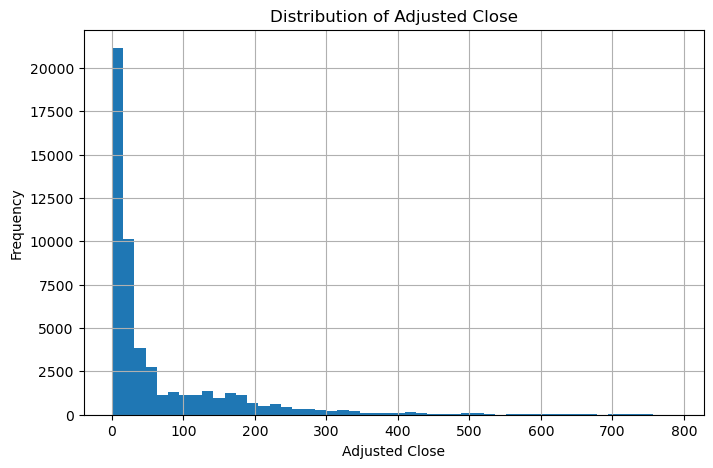

In [28]:
# Price distribution
import matplotlib.pyplot as plt

master["adj_close"].hist(bins=50, figsize=(8,5))
plt.title("Distribution of Adjusted Close")
plt.xlabel("Adjusted Close")
plt.ylabel("Frequency")
plt.show()

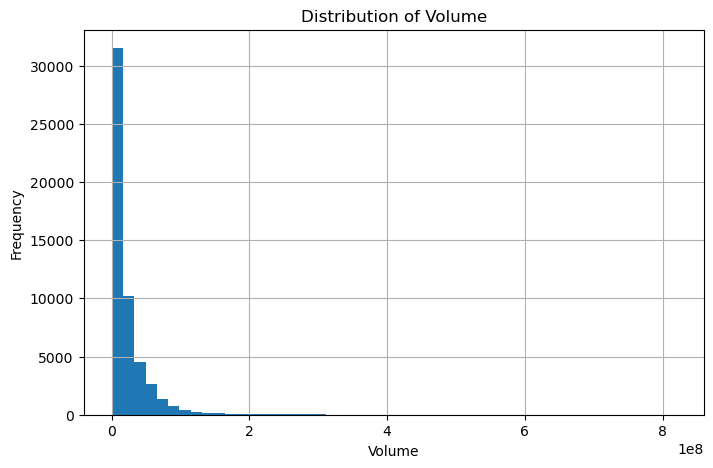

In [29]:
# Volume distribution
master["volume"].hist(bins=50, figsize=(8,5))
plt.title("Distribution of Volume")
plt.xlabel("Volume")
plt.ylabel("Frequency")
plt.show()

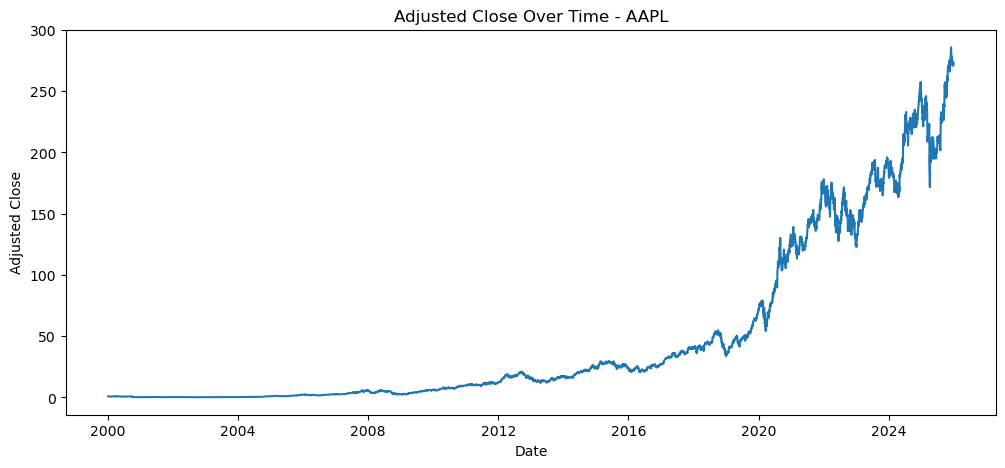

In [30]:
# One ticker price trand example
ticker_example = master[master["symbol"] == master["symbol"].unique()[0]]

plt.figure(figsize=(12,5))
plt.plot(ticker_example["date"], ticker_example["adj_close"])
plt.title(f"Adjusted Close Over Time - {ticker_example['symbol'].iloc[0]}")
plt.xlabel("Date")
plt.ylabel("Adjusted Close")
plt.show()

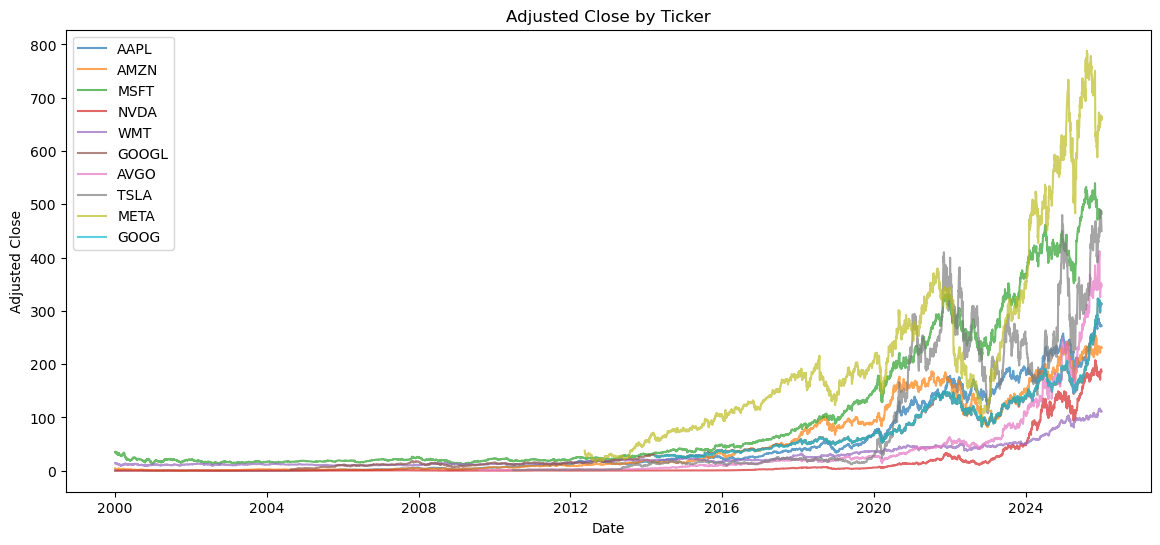

In [31]:
plt.figure(figsize=(14,6))
for sym in master["symbol"].unique():
    temp = master[master["symbol"] == sym]
    plt.plot(temp["date"], temp["adj_close"], label=sym, alpha=0.7)

plt.title("Adjusted Close by Ticker")
plt.xlabel("Date")
plt.ylabel("Adjusted Close")
plt.legend()
plt.show()

### Feature Engineering on Merged dataset

In [32]:
# Start feature engineering on merged master
master = master.sort_values(["symbol", "date"]).reset_index(drop=True)

master["return_1d"] = master.groupby("symbol")["adj_close"].pct_change()
master["log_return"] = master.groupby("symbol")["adj_close"].transform(
    lambda x: np.log(x / x.shift(1))
)

In [33]:
master[["symbol", "date", "adj_close", "return_1d", "log_return"]].head(10)

,symbol,date,adj_close,return_1d,log_return
0,AAPL,2000-01-03,0.8385,NaN,NaN
1,AAPL,2000-01-04,0.7678,-0.0843,-0.0881
2,AAPL,2000-01-05,0.7790,0.0146,0.0145
3,AAPL,2000-01-06,0.7116,-0.0865,-0.0905
4,AAPL,2000-01-07,0.7453,0.0474,0.0463
5,AAPL,2000-01-10,0.7322,-0.0176,-0.0177
6,AAPL,2000-01-11,0.6947,-0.0512,-0.0525
7,AAPL,2000-01-12,0.6531,-0.0599,-0.0618
8,AAPL,2000-01-13,0.7247,0.1096,0.1040
9,AAPL,2000-01-14,0.7523,0.0381,0.0374


In [34]:
# Momentum features
master["momentum_1m"] = master.groupby("symbol")["adj_close"].pct_change(21)
master["momentum_3m"] = master.groupby("symbol")["adj_close"].pct_change(63)
master["momentum_6m"] = master.groupby("symbol")["adj_close"].pct_change(126)

In [35]:
# Moving averages

master["ma_20"] = master.groupby("symbol")["adj_close"].transform(lambda x: x.rolling(20).mean())
master["ma_50"] = master.groupby("symbol")["adj_close"].transform(lambda x: x.rolling(50).mean())
master["ma_200"] = master.groupby("symbol")["adj_close"].transform(lambda x: x.rolling(200).mean())

master["price_vs_ma50"] = master["adj_close"] / master["ma_50"] - 1
master["price_vs_ma200"] = master["adj_close"] / master["ma_200"] - 1

In [36]:
# Volatility features
master["vol_20"] = master.groupby("symbol")["return_1d"].transform(
    lambda x: x.rolling(20).std() * np.sqrt(252)
)

master["vol_60"] = master.groupby("symbol")["return_1d"].transform(
    lambda x: x.rolling(60).std() * np.sqrt(252)
)

In [37]:
# Parkinson volatility

master["parkinson_daily"] = (np.log(master["high"] / master["low"])) ** 2

master["parkinson_vol_20"] = master.groupby("symbol")["parkinson_daily"].transform(
    lambda x: np.sqrt((1 / (4 * np.log(2))) * x.rolling(20).mean()) * np.sqrt(252)
)

In [38]:
# Intraday range
master["intraday_range"] = (master["high"] - master["low"]) / master["close"]

In [39]:
# Drawdown features
master["rolling_max"] = master.groupby("symbol")["adj_close"].transform(lambda x: x.cummax())
master["drawdown"] = master["adj_close"] / master["rolling_max"] - 1
master["drawdown_regime"] = np.where(master["drawdown"] < -0.20, 1, 0)

In [40]:
# Volume features
master["volume_change"] = master.groupby("symbol")["volume"].pct_change()

master["volume_ma20"] = master.groupby("symbol")["volume"].transform(
    lambda x: x.rolling(20).mean()
)

master["volume_spike"] = master["volume"] / master["volume_ma20"]

In [41]:
# Dividend feature
master["dividend_yield_daily"] = master["dividend"] / master["adj_close"]

### Create simple financial ratios

In [42]:
# Debt and equity features
master["debt_to_equity"] = master["totalLiabilities"] / master["totalShareholderEquity"]
master["asset_to_liability"] = master["totalAssets"] / master["totalLiabilities"]
master["cash_to_assets"] = master["cashAndCashEquivalentsAtCarryingValue"] / master["totalAssets"]

In [43]:
# Per-share / book features

master["book_value_per_share_proxy"] = master["totalShareholderEquity"] / master["commonStockSharesOutstanding"]
master["price_to_book_proxy"] = master["adj_close"] / master["book_value_per_share_proxy"]

In [44]:
# Margin proxies
master["gross_margin"] = master["grossProfit"] / master["totalRevenue"]
master["operating_margin_calc"] = master["operatingIncome"] / master["totalRevenue"]
master["net_margin_calc"] = master["netIncome"] / master["totalRevenue"]

In [45]:
# cashflow ratio
master["operating_cf_to_assets"] = master["operatingCashflow"] / master["totalAssets"]
master["capex_to_assets"] = master["capitalExpenditures"] / master["totalAssets"]


In [46]:
feature_cols_preview = [
    "return_1d", "log_return",
    "momentum_1m", "momentum_3m", "momentum_6m",
    "ma_20", "ma_50", "ma_200",
    "price_vs_ma50", "price_vs_ma200",
    "vol_20", "vol_60", "parkinson_vol_20",
    "intraday_range",
    "drawdown", "drawdown_regime",
    "volume_change", "volume_ma20", "volume_spike",
    "dividend_yield_daily",
    "debt_to_equity", "asset_to_liability", "cash_to_assets",
    "book_value_per_share_proxy", "price_to_book_proxy",
    "gross_margin", "operating_margin_calc", "net_margin_calc",
    "operating_cf_to_assets", "capex_to_assets"
]

master[["symbol", "date"] + feature_cols_preview].head(5)

,symbol,date,return_1d,log_return,momentum_1m,momentum_3m,momentum_6m,ma_20,ma_50,ma_200,price_vs_ma50,price_vs_ma200,vol_20,vol_60,parkinson_vol_20,intraday_range,drawdown,drawdown_regime,volume_change,volume_ma20,volume_spike,dividend_yield_daily,debt_to_equity,asset_to_liability,cash_to_assets,book_value_per_share_proxy,price_to_book_proxy,gross_margin,operating_margin_calc,net_margin_calc,operating_cf_to_assets,capex_to_assets
0,AAPL,2000-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0966,0.0000,0,NaN,NaN,NaN,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,AAPL,2000-01-04,-0.0843,-0.0881,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0920,-0.0843,0,-0.0437,NaN,NaN,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,AAPL,2000-01-05,0.0146,0.0145,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0727,-0.0709,0,0.5190,NaN,NaN,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,AAPL,2000-01-06,-0.0865,-0.0905,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.1263,-0.1513,0,-0.0133,NaN,NaN,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,AAPL,2000-01-07,0.0474,0.0463,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0553,-0.1111,0,-0.4001,NaN,NaN,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [47]:
### Summary stats for features columns
master[feature_cols_preview].describe().T

,count,mean,std,min,25%,50%,75%,max
return_1d,52476.0000,0.0012,0.0260,-0.5187,-0.0097,0.0008,0.0119,0.4241
log_return,52476.0000,0.0008,0.0260,-0.7312,-0.0098,0.0008,0.0118,0.3535
momentum_1m,52276.0000,0.0246,0.1172,-0.6898,-0.0354,0.0204,0.0771,2.0315
momentum_3m,51856.0000,0.0753,0.2157,-0.7707,-0.0413,0.0576,0.1654,2.2046
momentum_6m,51226.0000,0.1567,0.3494,-0.8593,-0.0242,0.1125,0.2761,5.1148
ma_20,52296.0000,65.0443,99.6124,0.0657,8.5358,20.7507,83.4508,762.4668
ma_50,51996.0000,64.4240,98.2884,0.0735,8.6794,20.6850,82.5131,752.1692
ma_200,50496.0000,61.6071,91.6967,0.0922,8.9446,20.4431,77.7555,677.0059
price_vs_ma50,51996.0000,0.0233,0.0999,-0.6165,-0.0259,0.0233,0.0723,0.9725
price_vs_ma200,50496.0000,0.0968,0.2144,-0.8066,-0.0131,0.0859,0.1912,1.9828


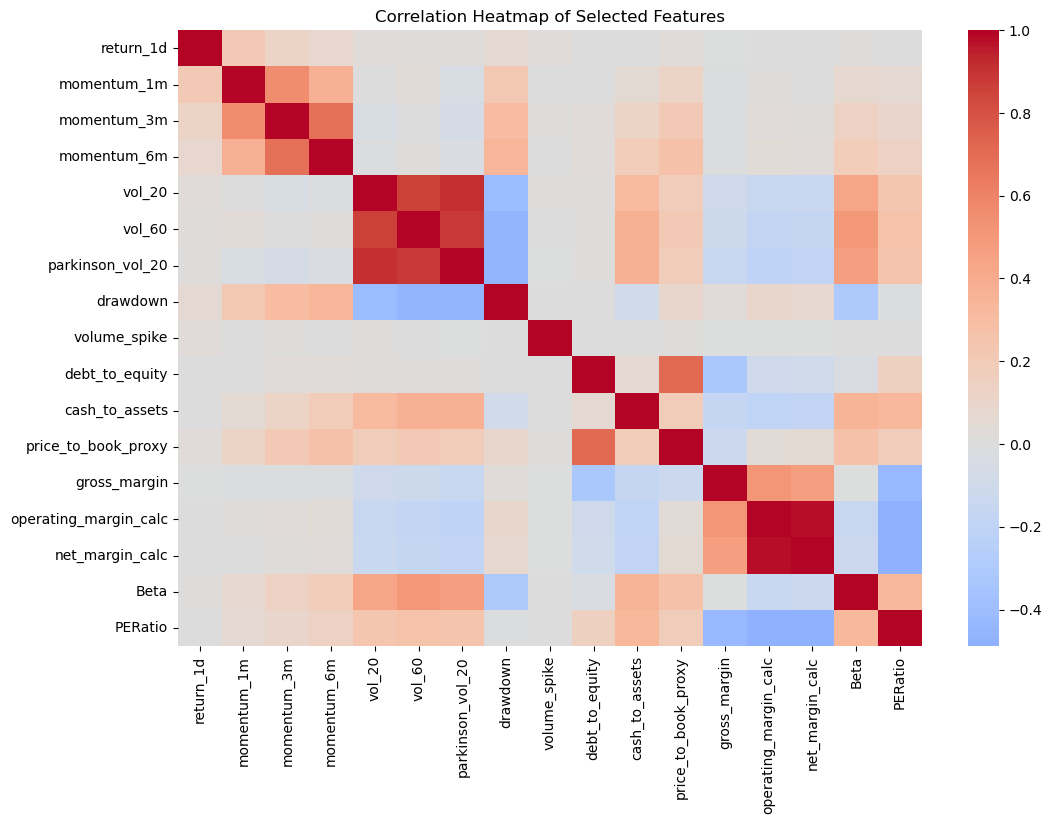

In [48]:
# Correlation heatmap
import seaborn as sns
import matplotlib.pyplot as plt

corr_cols = [
    "return_1d", "momentum_1m", "momentum_3m", "momentum_6m",
    "vol_20", "vol_60", "parkinson_vol_20",
    "drawdown", "volume_spike",
    "debt_to_equity", "cash_to_assets",
    "price_to_book_proxy", "gross_margin",
    "operating_margin_calc", "net_margin_calc",
    "Beta", "PERatio"
]

corr_df = master[corr_cols].copy()
corr = corr_df.corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap of Selected Features")
plt.show()

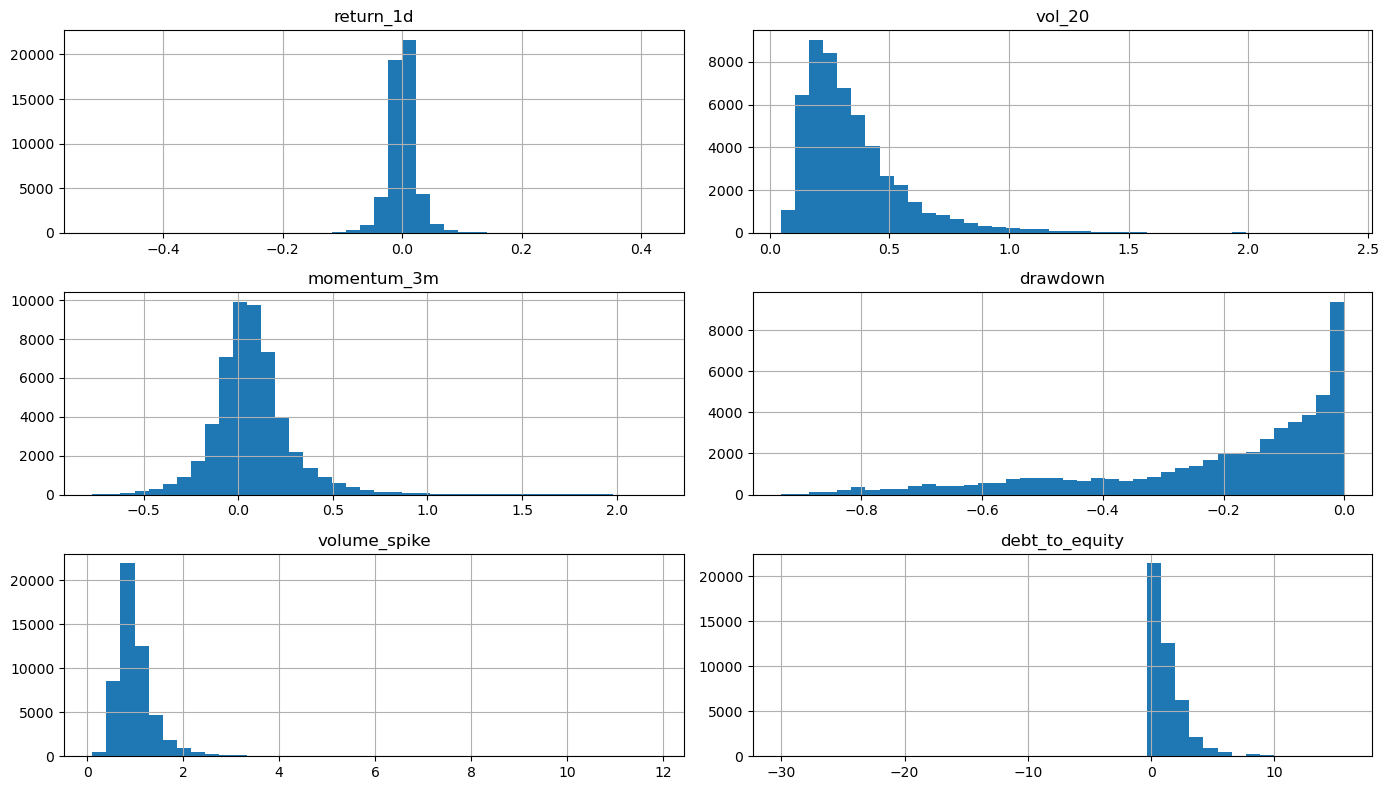

In [49]:
# Histograms of key features
key_hist_cols = ["return_1d", "vol_20", "momentum_3m", "drawdown", "volume_spike", "debt_to_equity"]

master[key_hist_cols].hist(bins=40, figsize=(14,8))
plt.tight_layout()
plt.show()

In [50]:
#handle infinite values cretaed by master
master = master.replace([np.inf, -np.inf], np.nan)

In [51]:
master[feature_cols_preview].isnull().sum().sort_values(ascending=False).head(20)

capex_to_assets               7924
book_value_per_share_proxy    7924
asset_to_liability            7924
debt_to_equity                7924
price_to_book_proxy           7924
gross_margin                  7924
operating_margin_calc         7924
net_margin_calc               7924
operating_cf_to_assets        7924
cash_to_assets                7924
price_vs_ma200                1990
ma_200                        1990
momentum_6m                   1260
momentum_3m                    630
vol_60                         600
price_vs_ma50                  490
ma_50                          490
momentum_1m                    210
vol_20                         200
parkinson_vol_20               190
dtype: int64

In [52]:
# Drop the null rows existing due to rolling features
master = master.dropna().reset_index(drop=True)

print("Final dataset shape:", master.shape)

Final dataset shape: (43766, 79)


In [53]:
# Saved merged and Engineered dataset
OUT_FEATURE_PATH = BASE / "master_price_fundamentals_features.parquet"
master.to_parquet(OUT_FEATURE_PATH, index=False)

print("Saved:", OUT_FEATURE_PATH)

Saved: ../data/clean/master_price_fundamentals_features.parquet


In [54]:
print(master.shape)
print(master.columns.tolist())
master.head()

(43766, 79)
['date', 'symbol', 'open', 'high', 'low', 'close', 'adj_close', 'volume', 'dividend', 'split_coeff', 'fiscalDateEnding', 'totalRevenue', 'grossProfit', 'operatingIncome', 'operatingExpenses', 'ebit', 'ebitda', 'totalAssets', 'totalCurrentAssets', 'cashAndCashEquivalentsAtCarryingValue', 'totalLiabilities', 'totalCurrentLiabilities', 'longTermDebt', 'totalShareholderEquity', 'commonStockSharesOutstanding', 'operatingCashflow', 'capitalExpenditures', 'cashflowFromInvestment', 'cashflowFromFinancing', 'dividendPayout', 'netIncome', 'MarketCapitalization', 'PERatio', 'BookValue', 'DividendYield', 'EPS', 'RevenueTTM', 'ProfitMargin', 'OperatingMarginTTM', 'ReturnOnAssetsTTM', 'ReturnOnEquityTTM', 'Beta', '52WeekHigh', '52WeekLow', '50DayMovingAverage', '200DayMovingAverage', 'SharesOutstanding', 'return_1d', 'log_return', 'momentum_1m', 'momentum_3m', 'momentum_6m', 'ma_20', 'ma_50', 'ma_200', 'price_vs_ma50', 'price_vs_ma200', 'vol_20', 'vol_60', 'parkinson_daily', 'parkinson_v

,date,symbol,open,high,low,close,adj_close,volume,dividend,split_coeff,fiscalDateEnding,totalRevenue,grossProfit,operatingIncome,operatingExpenses,ebit,ebitda,totalAssets,totalCurrentAssets,cashAndCashEquivalentsAtCarryingValue,totalLiabilities,totalCurrentLiabilities,longTermDebt,totalShareholderEquity,commonStockSharesOutstanding,operatingCashflow,capitalExpenditures,cashflowFromInvestment,cashflowFromFinancing,dividendPayout,netIncome,MarketCapitalization,PERatio,BookValue,DividendYield,EPS,RevenueTTM,ProfitMargin,OperatingMarginTTM,ReturnOnAssetsTTM,ReturnOnEquityTTM,Beta,52WeekHigh,52WeekLow,50DayMovingAverage,200DayMovingAverage,SharesOutstanding,return_1d,log_return,momentum_1m,momentum_3m,momentum_6m,ma_20,ma_50,ma_200,price_vs_ma50,price_vs_ma200,vol_20,vol_60,parkinson_daily,parkinson_vol_20,intraday_range,rolling_max,drawdown,drawdown_regime,volume_change,volume_ma20,volume_spike,dividend_yield_daily,debt_to_equity,asset_to_liability,cash_to_assets,book_value_per_share_proxy,price_to_book_proxy,gross_margin,operating_margin_calc,net_margin_calc,operating_cf_to_assets,capex_to_assets
0,2006-01-03,AAPL,72.3320,74.7500,72.2500,74.7500,2.2397,28829800,0.0000,1.0000,2005-12-31,5749000000.0000,1564000000.0000,750000000.0000,814000000.0000,750000000.0000,802000000.0000,14181000000.0000,11691000000.0000,4150000000.0000,5801000000.0000,5060000000.0000,0.0000,8380000000.0000,24477796000.0000,283000000.0000,82000000.0000,93000000.0000,283000000.0000,2488000000.0000,565000000.0000,3659195744000,31.5500,6.0000,0.0041,7.8900,435617006000,0.2700,0.3540,0.2440,1.5200,1.1160,288.3500,168.4800,261.6400,246.3600,14681140000,0.0398,0.0390,0.0440,0.3731,0.9681,2.1927,1.9989,1.4630,0.1205,0.5309,0.2869,0.3896,0.0012,0.2094,0.0334,2.2466,-0.0031,0,0.2931,21719185.0000,1.3274,0.0000,0.6922,2.4446,0.2926,0.3424,6.5420,0.2720,0.1305,0.0983,0.0200,0.0058
1,2006-01-04,AAPL,75.1300,75.9800,74.5000,74.9700,2.2463,22128700,0.0000,1.0000,2005-12-31,5749000000.0000,1564000000.0000,750000000.0000,814000000.0000,750000000.0000,802000000.0000,14181000000.0000,11691000000.0000,4150000000.0000,5801000000.0000,5060000000.0000,0.0000,8380000000.0000,24477796000.0000,283000000.0000,82000000.0000,93000000.0000,283000000.0000,2488000000.0000,565000000.0000,3659195744000,31.5500,6.0000,0.0041,7.8900,435617006000,0.2700,0.3540,0.2440,1.5200,1.1160,288.3500,168.4800,261.6400,246.3600,14681140000,0.0029,0.0029,0.0322,0.3948,1.0051,2.1975,2.0104,1.4677,0.1173,0.5305,0.2829,0.3886,0.0004,0.2114,0.0197,2.2466,-0.0001,0,-0.2324,21783350.0000,1.0159,0.0000,0.6922,2.4446,0.2926,0.3424,6.5613,0.2720,0.1305,0.0983,0.0200,0.0058
2,2006-01-05,AAPL,74.8300,74.9000,73.7500,74.3800,2.2286,16050800,0.0000,1.0000,2005-12-31,5749000000.0000,1564000000.0000,750000000.0000,814000000.0000,750000000.0000,802000000.0000,14181000000.0000,11691000000.0000,4150000000.0000,5801000000.0000,5060000000.0000,0.0000,8380000000.0000,24477796000.0000,283000000.0000,82000000.0000,93000000.0000,283000000.0000,2488000000.0000,565000000.0000,3659195744000,31.5500,6.0000,0.0041,7.8900,435617006000,0.2700,0.3540,0.2440,1.5200,1.1160,288.3500,168.4800,261.6400,246.3600,14681140000,-0.0079,-0.0079,0.0356,0.4092,0.9766,2.1979,2.0210,1.4724,0.1027,0.5136,0.2635,0.3864,0.0002,0.2096,0.0155,2.2466,-0.0080,0,-0.2747,21055480.0000,0.7623,0.0000,0.6922,2.4446,0.2926,0.3424,6.5096,0.2720,0.1305,0.0983,0.0200,0.0058
3,2006-01-06,AAPL,75.2400,76.7000,74.5500,76.3000,2.2861,25159200,0.0000,1.0000,2005-12-31,5749000000.0000,1564000000.0000,750000000.0000,814000000.0000,750000000.0000,802000000.0000,14181000000.0000,11691000000.0000,4150000000.0000,5801000000.0000,5060000000.0000,0.0000,8380000000.0000,24477796000.0000,283000000.0000,82000000.0000,93000000.0000,283000000.0000,2488000000.0000,565000000.0000,3659195744000,31.5500,6.0000,0.0041,7.8900,435617006000,0.2700,0.3540,0.2440,1.5200,1.1160,288.3500,168.4800,261.6400,246.3600,14681140000,0.0258,0.0255,0.0304,0.4758,0.9948,2.2015,2.0331,1.4775,0.1245,0.5473,0.

In [55]:
# =========================
# STEP 1: PREPARE OPTIONS
# =========================

options["trade_date"] = pd.to_datetime(options["trade_date"])
options["expiration"] = pd.to_datetime(options["expiration"])

# keep only call options
calls = options[options["call_put"].str.lower() == "call"].copy()


In [56]:
# Merge daily stock prices into options
price_lookup = master[["symbol", "date", "adj_close"]].rename(
    columns={"date": "trade_date", "adj_close": "stock_price"}
)

calls = calls.merge(
    price_lookup,
    on=["symbol", "trade_date"],
    how="inner"
)

# compute dte
calls["dte"] = (calls["expiration"] - calls["trade_date"]).dt.days
calls = calls[calls["dte"] > 0].copy()

In [ ]:
# Filter to reasonable delta range
calls_filtered = calls[(calls["delta"] >= 0.10) & (calls["delta"] <= 0.70)].copy()

def assign_moneyness_bucket(delta):
    if 0.10 <= delta < 0.35:
        return "OTM10"
    elif 0.36 <= delta < 0.67:
        return "OTM5"
    elif 0.68 <= delta <= 0.70:
        return "ATM"
    else:
        return "OUT_OF_RANGE"

calls_filtered["moneyness_bucket"] = calls_filtered["delta"].apply(assign_moneyness_bucket)
calls_filtered = calls_filtered[calls_filtered["moneyness_bucket"] != "OUT_OF_RANGE"].copy()

def assign_dte_bucket(dte):
    if 7 <= dte <= 30:
        return "30"
    elif 31 <= dte <= 90:
        return "60"
    elif  91 <= dte <= 120:
        return "90"
    else:
        return "OUT_OF_RANGE"

calls_filtered["dte_bucket"] = calls_filtered["dte"].apply(assign_dte_bucket)
calls_filtered = calls_filtered[calls_filtered["dte_bucket"] != "OUT_OF_RANGE"].copy()

In [58]:
# make sure option numeric columns are numeric
numeric_cols = [
    "strike", "bid", "ask", "last", "volume", "open_interest",
    "implied_vol", "delta", "gamma", "theta", "vega", "rho"
]

for col in numeric_cols:
    if col in calls.columns:
        calls[col] = pd.to_numeric(calls[col], errors="coerce")

# rebuild calls_filtered after numeric conversion if needed
calls_filtered = calls[(calls["delta"] >= 0.10) & (calls["delta"] <= 0.70)].copy()

calls_filtered["moneyness_bucket"] = calls_filtered["delta"].apply(assign_moneyness_bucket)
calls_filtered = calls_filtered[calls_filtered["moneyness_bucket"] != "OUT_OF_RANGE"].copy()

calls_filtered["dte_bucket"] = calls_filtered["dte"].apply(assign_dte_bucket)
calls_filtered = calls_filtered[calls_filtered["dte_bucket"] != "OUT_OF_RANGE"].copy()

calls_filtered["bucket_label"] = (
    calls_filtered["moneyness_bucket"] + "_" + calls_filtered["dte_bucket"]
)

calls_filtered["premium"] = (calls_filtered["bid"] + calls_filtered["ask"]) / 2

In [59]:
# Build final contract bucket label
calls_filtered["bucket_label"] = (
    calls_filtered["moneyness_bucket"] + "_" + calls_filtered["dte_bucket"]
)

# compute premium
calls_filtered["premium"] = (calls_filtered["bid"] + calls_filtered["ask"]) / 2

In [60]:
# =====================================================
# SAFE OPTION FEATURES (trade-date only, no leakage)
# =====================================================

option_features = (
    calls_filtered
    .groupby(["symbol", "trade_date"], as_index=False)
    .agg(
        opt_contract_count=("delta", "count"),
        opt_delta_mean=("delta", "mean"),
        opt_delta_median=("delta", "median"),
        opt_dte_mean=("dte", "mean"),
        opt_dte_median=("dte", "median"),
        opt_iv_mean=("implied_vol", "mean"),
        opt_iv_median=("implied_vol", "median"),
        opt_open_interest_sum=("open_interest", "sum"),
        opt_open_interest_mean=("open_interest", "mean"),
        opt_volume_sum=("volume", "sum"),
        opt_volume_mean=("volume", "mean"),
        opt_theta_mean=("theta", "mean"),
        opt_vega_mean=("vega", "mean"),
        opt_premium_mean=("premium", "mean"),
        opt_premium_median=("premium", "median")
    )
    .rename(columns={"trade_date": "date"})
)

print("General option features shape:", option_features.shape)
option_features.head()

General option features shape: (1511, 17)


,symbol,date,opt_contract_count,opt_delta_mean,opt_delta_median,opt_dte_mean,opt_dte_median,opt_iv_mean,opt_iv_median,opt_open_interest_sum,opt_open_interest_mean,opt_volume_sum,opt_volume_mean,opt_theta_mean,opt_vega_mean,opt_premium_mean,opt_premium_median
0,AAPL,2008-02-01,1,0.1813,0.1813,50.0000,50.0000,0.0149,0.0149,5024,5024.0000,5629,5629.0000,-0.0040,0.1305,7.9250,7.9250
1,AAPL,2008-04-01,3,0.4854,0.4906,57.6667,46.0000,0.0149,0.0149,63327,21109.0000,33649,11216.3333,-0.0080,0.2039,9.9667,10.0750
2,AAPL,2008-05-01,1,0.6200,0.6200,16.0000,16.0000,0.0149,0.0149,30733,30733.0000,19975,19975.0000,-0.0133,0.1435,5.3250,5.3250
3,AAPL,2008-07-01,2,0.4848,0.4848,32.0000,32.0000,0.0149,0.0149,39637,19818.5000,49935,24967.5000,-0.0100,0.1974,8.7125,8.7125
4,AAPL,2008-10-01,2,0.2065,0.2065,80.0000,80.0000,0.0149,0.0149,10296,5148.0000,4006,2003.0000,-0.0020,0.1439,14.6000,14.6000


### moneyness bucket option features

In [61]:
moneyness_features = (
    calls_filtered
    .groupby(["symbol", "trade_date", "moneyness_bucket"], as_index=False)
    .agg(
        m_bucket_count=("delta", "count"),
        m_delta_mean=("delta", "mean"),
        m_iv_mean=("implied_vol", "mean"),
        m_premium_mean=("premium", "mean"),
        m_oi_sum=("open_interest", "sum"),
        m_theta_mean=("theta", "mean"),
        m_vega_mean=("vega", "mean")
    )
)

moneyness_pivot = moneyness_features.pivot_table(
    index=["symbol", "trade_date"],
    columns="moneyness_bucket",
    values=[
        "m_bucket_count",
        "m_delta_mean",
        "m_iv_mean",
        "m_premium_mean",
        "m_oi_sum",
        "m_theta_mean",
        "m_vega_mean"
    ]
)

moneyness_pivot.columns = [
    f"{metric}_{bucket}" for metric, bucket in moneyness_pivot.columns
]

moneyness_pivot = (
    moneyness_pivot
    .reset_index()
    .rename(columns={"trade_date": "date"})
)

print("Moneyness option features shape:", moneyness_pivot.shape)
moneyness_pivot.head()

Moneyness option features shape: (1511, 23)


,symbol,date,m_bucket_count_ATM,m_bucket_count_OTM10,m_bucket_count_OTM5,m_delta_mean_ATM,m_delta_mean_OTM10,m_delta_mean_OTM5,m_iv_mean_ATM,m_iv_mean_OTM10,m_iv_mean_OTM5,m_oi_sum_ATM,m_oi_sum_OTM10,m_oi_sum_OTM5,m_premium_mean_ATM,m_premium_mean_OTM10,m_premium_mean_OTM5,m_theta_mean_ATM,m_theta_mean_OTM10,m_theta_mean_OTM5,m_vega_mean_ATM,m_vega_mean_OTM10,m_vega_mean_OTM5
0,AAPL,2008-02-01,NaN,1.0000,NaN,NaN,0.1813,NaN,NaN,0.0149,NaN,NaN,5024.0000,NaN,NaN,7.9250,NaN,NaN,-0.0040,NaN,NaN,0.1305,NaN
1,AAPL,2008-04-01,1.0000,1.0000,1.0000,0.6888,0.2767,0.4906,0.0149,0.0149,0.0149,16490.0000,39695.0000,7142.0000,14.5500,5.2750,10.0750,-0.0086,-0.0073,-0.0082,0.2888,0.1111,0.2117
2,AAPL,2008-05-01,NaN,NaN,1.0000,NaN,NaN,0.6200,NaN,NaN,0.0149,NaN,NaN,30733.0000,NaN,NaN,5.3250,NaN,NaN,-0.0133,NaN,NaN,0.1435
3,AAPL,2008-07-01,NaN,NaN,2.0000,NaN,NaN,0.4848,NaN,NaN,0.0149,NaN,NaN,39637.0000,NaN,NaN,8.7125,NaN,NaN,-0.0100,NaN,NaN,0.1974
4,AAPL,2008-10-01,NaN,2.0000,NaN,NaN,0.2065,NaN,NaN,0.0149,NaN,NaN,10296.0000,NaN,NaN,14.6000,NaN,NaN,-0.0020,NaN,NaN,0.1439,NaN


### DTE bucket code option features

In [62]:
dte_features = (
    calls_filtered
    .groupby(["symbol", "trade_date", "dte_bucket"], as_index=False)
    .agg(
        d_bucket_count=("delta", "count"),
        d_delta_mean=("delta", "mean"),
        d_iv_mean=("implied_vol", "mean"),
        d_premium_mean=("premium", "mean"),
        d_oi_sum=("open_interest", "sum"),
        d_theta_mean=("theta", "mean"),
        d_vega_mean=("vega", "mean")
    )
)

dte_pivot = dte_features.pivot_table(
    index=["symbol", "trade_date"],
    columns="dte_bucket",
    values=[
        "d_bucket_count",
        "d_delta_mean",
        "d_iv_mean",
        "d_premium_mean",
        "d_oi_sum",
        "d_theta_mean",
        "d_vega_mean"
    ]
)

dte_pivot.columns = [
    f"{metric}_{bucket}" for metric, bucket in dte_pivot.columns
]

dte_pivot = (
    dte_pivot
    .reset_index()
    .rename(columns={"trade_date": "date"})
)

print("DTE option features shape:", dte_pivot.shape)
dte_pivot.head()

DTE option features shape: (1511, 23)


,symbol,date,d_bucket_count_30,d_bucket_count_60,d_bucket_count_90,d_delta_mean_30,d_delta_mean_60,d_delta_mean_90,d_iv_mean_30,d_iv_mean_60,d_iv_mean_90,d_oi_sum_30,d_oi_sum_60,d_oi_sum_90,d_premium_mean_30,d_premium_mean_60,d_premium_mean_90,d_theta_mean_30,d_theta_mean_60,d_theta_mean_90,d_vega_mean_30,d_vega_mean_60,d_vega_mean_90
0,AAPL,2008-02-01,NaN,1.0000,NaN,NaN,0.1813,NaN,NaN,0.0149,NaN,NaN,5024.0000,NaN,NaN,7.9250,NaN,NaN,-0.0040,NaN,NaN,0.1305,NaN
1,AAPL,2008-04-01,1.0000,1.0000,1.0000,0.2767,0.4906,0.6888,0.0149,0.0149,0.0149,39695.0000,7142.0000,16490.0000,5.2750,10.0750,14.5500,-0.0073,-0.0082,-0.0086,0.1111,0.2117,0.2888
2,AAPL,2008-05-01,1.0000,NaN,NaN,0.6200,NaN,NaN,0.0149,NaN,NaN,30733.0000,NaN,NaN,5.3250,NaN,NaN,-0.0133,NaN,NaN,0.1435,NaN,NaN
3,AAPL,2008-07-01,1.0000,1.0000,NaN,0.4062,0.5634,NaN,0.0149,0.0149,NaN,36612.0000,3025.0000,NaN,5.8250,11.6000,NaN,-0.0103,-0.0096,NaN,0.1505,0.2443,NaN
4,AAPL,2008-10-01,NaN,1.0000,1.0000,NaN,0.1280,0.2850,NaN,0.0149,0.0149,NaN,2866.0000,7430.0000,NaN,12.8250,16.3750,NaN,-0.0017,-0.0024,NaN,0.0862,0.2015


### merge option features to master

In [63]:
master_opt = master.merge(
    option_features,
    on=["symbol", "date"],
    how="left"
)

master_opt = master_opt.merge(
    moneyness_pivot,
    on=["symbol", "date"],
    how="left"
)

master_opt = master_opt.merge(
    dte_pivot,
    on=["symbol", "date"],
    how="left"
)

print("master_opt shape:", master_opt.shape)
print("Duplicate symbol-date rows:", master_opt.duplicated(subset=["symbol", "date"]).sum())
master_opt.head()

master_opt shape: (43766, 136)
Duplicate symbol-date rows: 0


,date,symbol,open,high,low,close,adj_close,volume,dividend,split_coeff,fiscalDateEnding,totalRevenue,grossProfit,operatingIncome,operatingExpenses,ebit,ebitda,totalAssets,totalCurrentAssets,cashAndCashEquivalentsAtCarryingValue,totalLiabilities,totalCurrentLiabilities,longTermDebt,totalShareholderEquity,commonStockSharesOutstanding,operatingCashflow,capitalExpenditures,cashflowFromInvestment,cashflowFromFinancing,dividendPayout,netIncome,MarketCapitalization,PERatio,BookValue,DividendYield,EPS,RevenueTTM,ProfitMargin,OperatingMarginTTM,ReturnOnAssetsTTM,ReturnOnEquityTTM,Beta,52WeekHigh,52WeekLow,50DayMovingAverage,200DayMovingAverage,SharesOutstanding,return_1d,log_return,momentum_1m,momentum_3m,momentum_6m,ma_20,ma_50,ma_200,price_vs_ma50,price_vs_ma200,vol_20,vol_60,parkinson_daily,parkinson_vol_20,intraday_range,rolling_max,drawdown,drawdown_regime,volume_change,volume_ma20,volume_spike,dividend_yield_daily,debt_to_equity,asset_to_liability,cash_to_assets,book_value_per_share_proxy,price_to_book_proxy,gross_margin,operating_margin_calc,net_margin_calc,operating_cf_to_assets,capex_to_assets,opt_contract_count,opt_delta_mean,opt_delta_median,opt_dte_mean,opt_dte_median,opt_iv_mean,opt_iv_median,opt_open_interest_sum,opt_open_interest_mean,opt_volume_sum,opt_volume_mean,opt_theta_mean,opt_vega_mean,opt_premium_mean,opt_premium_median,m_bucket_count_ATM,m_bucket_count_OTM10,m_bucket_count_OTM5,m_delta_mean_ATM,m_delta_mean_OTM10,m_delta_mean_OTM5,m_iv_mean_ATM,m_iv_mean_OTM10,m_iv_mean_OTM5,m_oi_sum_ATM,m_oi_sum_OTM10,m_oi_sum_OTM5,m_premium_mean_ATM,m_premium_mean_OTM10,m_premium_mean_OTM5,m_theta_mean_ATM,m_theta_mean_OTM10,m_theta_mean_OTM5,m_vega_mean_ATM,m_vega_mean_OTM10,m_vega_mean_OTM5,d_bucket_count_30,d_bucket_count_60,d_bucket_count_90,d_delta_mean_30,d_delta_mean_60,d_delta_mean_90,d_iv_mean_30,d_iv_mean_60,d_iv_mean_90,d_oi_sum_30,d_oi_sum_60,d_oi_sum_90,d_premium_mean_30,d_premium_mean_60,d_premium_mean_90,d_theta_mean_30,d_theta_mean_60,d_theta_mean_90,d_vega_mean_30,d_vega_mean_60,d_vega_mean_90
0,2006-01-03,AAPL,72.3320,74.7500,72.2500,74.7500,2.2397,28829800,0.0000,1.0000,2005-12-31,5749000000.0000,1564000000.0000,750000000.0000,814000000.0000,750000000.0000,802000000.0000,14181000000.0000,11691000000.0000,4150000000.0000,5801000000.0000,5060000000.0000,0.0000,8380000000.0000,24477796000.0000,283000000.0000,82000000.0000,93000000.0000,283000000.0000,2488000000.0000,565000000.0000,3659195744000,31.5500,6.0000,0.0041,7.8900,435617006000,0.2700,0.3540,0.2440,1.5200,1.1160,288.3500,168.4800,261.6400,246.3600,14681140000,0.0398,0.0390,0.0440,0.3731,0.9681,2.1927,1.9989,1.4630,0.1205,0.5309,0.2869,0.3896,0.0012,0.2094,0.0334,2.2466,-0.0031,0,0.2931,21719185.0000,1.3274,0.0000,0.6922,2.4446,0.2926,0.3424,6.5420,0.2720,0.1305,0.0983,0.0200,0.0058,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2006-01-04,AAPL,75.1300,75.9800,74.5000,74.9700,2.2463,22128700,0.0000,1.0000,2005-12-31,5749000000.0000,1564000000.0000,750000000.0000,814000000.0000,750000000.0000,802000000.0000,14181000000.0000,11691000000.0000,4150000000.0000,5801000000.0000,5060000000.0000,0.0000,8380000000.0000,24477796000.0000,283000000.0000,82000000.0000,93000000.0000,283000000.0000,2488000000.0000,565000000.0000,3659195744000,31.5500,6.0000,0.0041,7.8900,435617006000,0.2700,0.3540,0.2440,1.5200,1.1160,288.3500,168.4800,261.6400,246.3600,14681140000,0.0029,0.0029,0.0322,0.3948,1.0051,2.1975,2.0104,1.4677,0.1173,0.5305,0.2829,0.3886,0.0004,0.2114,0.0197,2.2466,-0.0001,0,-0.2324,21783350.0000,1.0159,0.0000,0.6922,2.4446,0.2926,0.3424,6.5613,0.2720,0.1305,0.0983,0.0200,0.0058,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

### Build label_df separate from feature engineering

In [64]:
# =====================================================
# STEP 5: BUILD LABEL_DF SEPARATELY (USES FUTURE INFO)
# =====================================================

calls_for_label = calls_filtered.copy()

In [65]:
# future stock price at expiration
future_prices = master[["symbol", "date", "adj_close"]].rename(
    columns={"date": "expiration", "adj_close": "future_price"}
)

calls_for_label = calls_for_label.merge(
    future_prices,
    on=["symbol", "expiration"],
    how="left"
)

calls_for_label = calls_for_label.dropna(subset=["future_price"]).copy()

print("calls_for_label after future price merge:", calls_for_label.shape)

calls_for_label after future price merge: (175143, 27)


In [66]:
# covered call return
calls_for_label["covered_call_payoff"] = (
    calls_for_label["premium"] +
    np.minimum(calls_for_label["future_price"], calls_for_label["strike"]) -
    calls_for_label["stock_price"]
)

calls_for_label["covered_call_return"] = (
    calls_for_label["covered_call_payoff"] / calls_for_label["stock_price"]
)

In [67]:
# Realized volatility over holding period

price_lookup_ret = master[["symbol", "date", "return_1d"]].copy()
price_lookup_ret = price_lookup_ret.sort_values(["symbol", "date"]).reset_index(drop=True)

def realized_vol_for_cycle(symbol, start_date, end_date, price_df):
    temp = price_df[
        (price_df["symbol"] == symbol) &
        (price_df["date"] >= start_date) &
        (price_df["date"] <= end_date)
    ].copy()

    if temp["return_1d"].dropna().shape[0] < 2:
        return np.nan

    return temp["return_1d"].std() * np.sqrt(252)

calls_for_label["realized_vol_cycle"] = calls_for_label.apply(
    lambda r: realized_vol_for_cycle(
        r["symbol"],
        r["trade_date"],
        r["expiration"],
        price_lookup_ret
    ),
    axis=1
)

In [68]:
# Risk free cycle return and Sharpe proxy

RISK_FREE = 0.05

calls_for_label["rf_cycle"] = (
    (1 + RISK_FREE) ** (calls_for_label["dte"] / 252) - 1
)

calls_for_label["sharpe_proxy"] = (
    (calls_for_label["covered_call_return"] - calls_for_label["rf_cycle"]) /
    calls_for_label["realized_vol_cycle"]
)

calls_for_label = calls_for_label.replace([np.inf, -np.inf], np.nan)

In [69]:
# Aggregate to bucket level

bucket_perf = (
    calls_for_label
    .dropna(subset=["sharpe_proxy"])
    .groupby(["symbol", "trade_date", "bucket_label"], as_index=False)
    .agg({
        "covered_call_return": "mean",
        "realized_vol_cycle": "mean",
        "rf_cycle": "mean",
        "sharpe_proxy": "mean"
    })
)

print("bucket_perf shape:", bucket_perf.shape)
bucket_perf.head()

bucket_perf shape: (9248, 7)


,symbol,trade_date,bucket_label,covered_call_return,realized_vol_cycle,rf_cycle,sharpe_proxy
0,AAPL,2010-07-01,OTM10_30,0.2900,0.2948,0.0016,0.9783
1,AAPL,2010-07-01,OTM5_30,0.6963,0.2948,0.0016,2.3566
2,AAPL,2010-10-01,OTM10_30,0.2145,0.2868,0.0014,0.7433
3,AAPL,2010-10-01,OTM5_30,0.7320,0.2868,0.0014,2.5474
4,AAPL,2011-04-01,OTM10_30,0.0962,0.0709,0.0014,1.3371


In [70]:
# Create label_df

label_df = (
    bucket_perf
    .sort_values(
        ["symbol", "trade_date", "sharpe_proxy"],
        ascending=[True, True, False]
    )
    .groupby(["symbol", "trade_date"], as_index=False)
    .first()
)

label_df = label_df.rename(
    columns={
        "trade_date": "date",
        "bucket_label": "optimal_bucket"
    }
)

print("label_df shape:", label_df.shape)
print(label_df["optimal_bucket"].value_counts())
label_df.head()

label_df shape: (1243, 7)
optimal_bucket
ATM_60      346
ATM_90      328
OTM10_90    162
OTM5_90     131
ATM_30      107
OTM10_60     50
OTM5_30      47
OTM5_60      39
OTM10_30     33
Name: count, dtype: int64


,symbol,date,optimal_bucket,covered_call_return,realized_vol_cycle,rf_cycle,sharpe_proxy
0,AAPL,2010-07-01,OTM5_30,0.6963,0.2948,0.0016,2.3566
1,AAPL,2010-10-01,OTM5_30,0.7320,0.2868,0.0014,2.5474
2,AAPL,2011-04-01,OTM5_30,0.3502,0.0709,0.0014,4.9194
3,AAPL,2011-07-01,OTM5_30,0.2662,0.1107,0.0014,2.3928
4,AAPL,2011-09-01,OTM5_30,0.6094,0.2277,0.0016,2.6696


In [71]:

# =====================================================
# STEP 6: MERGE ONLY TARGET INTO MASTER_OPT
# =====================================================

final_dataset = master_opt.merge(
    label_df[["symbol", "date", "optimal_bucket"]],
    on=["symbol", "date"],
    how="left"
)

final_dataset = final_dataset.sort_values(["symbol", "date"]).reset_index(drop=True)

final_dataset["optimal_bucket"] = (
    final_dataset.groupby("symbol")["optimal_bucket"]
    .transform(lambda x: x.ffill().bfill())
)

print("final_dataset shape:", final_dataset.shape)
print("Duplicate symbol-date rows:", final_dataset.duplicated(subset=["symbol", "date"]).sum())
print("Remaining missing optimal_bucket:", final_dataset["optimal_bucket"].isna().sum())

final_dataset.head()

final_dataset shape: (43766, 137)
Duplicate symbol-date rows: 0
Remaining missing optimal_bucket: 0


,date,symbol,open,high,low,close,adj_close,volume,dividend,split_coeff,fiscalDateEnding,totalRevenue,grossProfit,operatingIncome,operatingExpenses,ebit,ebitda,totalAssets,totalCurrentAssets,cashAndCashEquivalentsAtCarryingValue,totalLiabilities,totalCurrentLiabilities,longTermDebt,totalShareholderEquity,commonStockSharesOutstanding,operatingCashflow,capitalExpenditures,cashflowFromInvestment,cashflowFromFinancing,dividendPayout,netIncome,MarketCapitalization,PERatio,BookValue,DividendYield,EPS,RevenueTTM,ProfitMargin,OperatingMarginTTM,ReturnOnAssetsTTM,ReturnOnEquityTTM,Beta,52WeekHigh,52WeekLow,50DayMovingAverage,200DayMovingAverage,SharesOutstanding,return_1d,log_return,momentum_1m,momentum_3m,momentum_6m,ma_20,ma_50,ma_200,price_vs_ma50,price_vs_ma200,vol_20,vol_60,parkinson_daily,parkinson_vol_20,intraday_range,rolling_max,drawdown,drawdown_regime,volume_change,volume_ma20,volume_spike,dividend_yield_daily,debt_to_equity,asset_to_liability,cash_to_assets,book_value_per_share_proxy,price_to_book_proxy,gross_margin,operating_margin_calc,net_margin_calc,operating_cf_to_assets,capex_to_assets,opt_contract_count,opt_delta_mean,opt_delta_median,opt_dte_mean,opt_dte_median,opt_iv_mean,opt_iv_median,opt_open_interest_sum,opt_open_interest_mean,opt_volume_sum,opt_volume_mean,opt_theta_mean,opt_vega_mean,opt_premium_mean,opt_premium_median,m_bucket_count_ATM,m_bucket_count_OTM10,m_bucket_count_OTM5,m_delta_mean_ATM,m_delta_mean_OTM10,m_delta_mean_OTM5,m_iv_mean_ATM,m_iv_mean_OTM10,m_iv_mean_OTM5,m_oi_sum_ATM,m_oi_sum_OTM10,m_oi_sum_OTM5,m_premium_mean_ATM,m_premium_mean_OTM10,m_premium_mean_OTM5,m_theta_mean_ATM,m_theta_mean_OTM10,m_theta_mean_OTM5,m_vega_mean_ATM,m_vega_mean_OTM10,m_vega_mean_OTM5,d_bucket_count_30,d_bucket_count_60,d_bucket_count_90,d_delta_mean_30,d_delta_mean_60,d_delta_mean_90,d_iv_mean_30,d_iv_mean_60,d_iv_mean_90,d_oi_sum_30,d_oi_sum_60,d_oi_sum_90,d_premium_mean_30,d_premium_mean_60,d_premium_mean_90,d_theta_mean_30,d_theta_mean_60,d_theta_mean_90,d_vega_mean_30,d_vega_mean_60,d_vega_mean_90,optimal_bucket
0,2006-01-03,AAPL,72.3320,74.7500,72.2500,74.7500,2.2397,28829800,0.0000,1.0000,2005-12-31,5749000000.0000,1564000000.0000,750000000.0000,814000000.0000,750000000.0000,802000000.0000,14181000000.0000,11691000000.0000,4150000000.0000,5801000000.0000,5060000000.0000,0.0000,8380000000.0000,24477796000.0000,283000000.0000,82000000.0000,93000000.0000,283000000.0000,2488000000.0000,565000000.0000,3659195744000,31.5500,6.0000,0.0041,7.8900,435617006000,0.2700,0.3540,0.2440,1.5200,1.1160,288.3500,168.4800,261.6400,246.3600,14681140000,0.0398,0.0390,0.0440,0.3731,0.9681,2.1927,1.9989,1.4630,0.1205,0.5309,0.2869,0.3896,0.0012,0.2094,0.0334,2.2466,-0.0031,0,0.2931,21719185.0000,1.3274,0.0000,0.6922,2.4446,0.2926,0.3424,6.5420,0.2720,0.1305,0.0983,0.0200,0.0058,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,OTM5_30
1,2006-01-04,AAPL,75.1300,75.9800,74.5000,74.9700,2.2463,22128700,0.0000,1.0000,2005-12-31,5749000000.0000,1564000000.0000,750000000.0000,814000000.0000,750000000.0000,802000000.0000,14181000000.0000,11691000000.0000,4150000000.0000,5801000000.0000,5060000000.0000,0.0000,8380000000.0000,24477796000.0000,283000000.0000,82000000.0000,93000000.0000,283000000.0000,2488000000.0000,565000000.0000,3659195744000,31.5500,6.0000,0.0041,7.8900,435617006000,0.2700,0.3540,0.2440,1.5200,1.1160,288.3500,168.4800,261.6400,246.3600,14681140000,0.0029,0.0029,0.0322,0.3948,1.0051,2.1975,2.0104,1.4677,0.1173,0.5305,0.2829,0.3886,0.0004,0.2114,0.0197,2.2466,-0.0001,0,-0.2324,21783350.0000,1.0159,0.0000,0.6922,2.4446,0.2926,0.3424,6.5613,0.2720,0.1305,0.0983,0.0200,0.0058,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N

In [72]:
# =====================================================
# STEP 7: CREATE TWO-STAGE TARGETS
# =====================================================

final_dataset["moneyness_target"] = final_dataset["optimal_bucket"].str.split("_").str[0]
final_dataset["dte_target"] = final_dataset["optimal_bucket"].str.split("_").str[1]

print(final_dataset["moneyness_target"].value_counts())
print(final_dataset["dte_target"].value_counts())

moneyness_target
ATM      24684
OTM5     10157
OTM10     8925
Name: count, dtype: int64
dte_target
60    15869
90    14643
30    13254
Name: count, dtype: int64


In [73]:
FINAL_MODEL_PATH = BASE / "daily_stock_optimal_bucket_two_stage_modeling.parquet"
final_dataset.to_parquet(FINAL_MODEL_PATH, index=False)

print("Saved:", FINAL_MODEL_PATH)

Saved: ../data/clean/daily_stock_optimal_bucket_two_stage_modeling.parquet
